# Morocco AFCON 2025 & FIFA World Cup 2030 Economic Pipeline

## Project Overview

Morocco will host AFCON 2025 and co-host the FIFA World Cup 2030.

These major sporting events require significant investments in infrastructure, transportation, tourism, and urban development.

The objective of this project is to analyze Morocco's economic readiness by combining:

- Economic indicators from the World Bank
- Tourism data
- Infrastructure projects
- Host city information

The project uses a complete Data Engineering workflow including ETL pipelines, PostgreSQL, Docker, and Apache Airflow.

## Project Architecture

The project follows the following workflow:

World Bank API / Project Data

↓

Extract

↓

Transform

↓

Load

↓

PostgreSQL

↓

Apache Airflow

↓

Notebook Analysis

↓

Streamlit Dashboard

## Importing Libraries

The following libraries are used for data manipulation, visualization, and database connectivity.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

## Connecting to PostgreSQL

All project datasets are stored in PostgreSQL.

In this step, we create a connection to the database in order to retrieve the data generated by the ETL pipelines.

In [36]:
DB_USER = "yassine"
DB_PASSWORD = "morocco2030"
DB_HOST = "localhost"
DB_PORT = "5433"
DB_NAME = "morocco_events_db"

engine = create_engine(
    f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

## Loading Project Data

The project contains four main datasets:

- Economic indicators
- Tourism data
- Infrastructure projects
- Host cities

These datasets will be used throughout the analysis.

In [37]:
economic_df = pd.read_sql(
    "SELECT * FROM economic_indicators",
    engine
)

tourism_df = pd.read_sql(
    "SELECT * FROM tourism_data",
    engine
)

infrastructure_df = pd.read_sql(
    "SELECT * FROM infrastructure_projects",
    engine
)

host_cities_df = pd.read_sql(
    "SELECT * FROM host_cities",
    engine
)

## Data Validation

Before starting the analysis, we verify that all datasets have been loaded successfully.

In [38]:
print("Economic Indicators:", economic_df.shape)
print("Tourism:", tourism_df.shape)
print("Infrastructure:", infrastructure_df.shape)
print("Host Cities:", host_cities_df.shape)

Economic Indicators: (330, 8)
Tourism: (132, 6)
Infrastructure: (19, 10)
Host Cities: (7, 7)


## Economic Indicators Dataset

Let's first explore the economic indicators dataset.

This dataset contains five indicators:

- GDP Growth
- GDP Per Capita
- Inflation
- Unemployment
- Foreign Direct Investment (FDI)

The data covers approximately 66 years of Morocco's economic history.

In [39]:
economic_df.head()

,id,country,indicator_code,indicator_name,year,value,source,created_at
0,1,Morocco,BX.KLT.DINV.CD.WD,Foreign direct investment net inflows,1960,NaN,World Bank API,2026-06-09 19:09:55.294107
1,2,Morocco,BX.KLT.DINV.CD.WD,Foreign direct investment net inflows,1961,NaN,World Bank API,2026-06-09 19:09:55.294107
2,3,Morocco,BX.KLT.DINV.CD.WD,Foreign direct investment net inflows,1962,NaN,World Bank API,2026-06-09 19:09:55.294107
3,4,Morocco,BX.KLT.DINV.CD.WD,Foreign direct investment net inflows,1963,NaN,World Bank API,2026-06-09 19:09:55.294107
4,5,Morocco,BX.KLT.DINV.CD.WD,Foreign direct investment net inflows,1964,NaN,World Bank API,2026-06-09 19:09:55.294107


## Dataset Information

Before analyzing trends, it is important to understand the structure of the dataset, the available columns, and the data types.

In [40]:
economic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              330 non-null    int64         
 1   country         330 non-null    str           
 2   indicator_code  330 non-null    str           
 3   indicator_name  330 non-null    str           
 4   year            330 non-null    int64         
 5   value           278 non-null    float64       
 6   source          330 non-null    str           
 7   created_at      330 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 20.8 KB


## Summary Statistics

Summary statistics provide an overview of the numerical variables contained in the dataset.

In [41]:
economic_df.describe()

,id,year,value,created_at
count,330.000000,330.000000,2.780000e+02,330
mean,165.500000,1992.500000,2.139141e+08,2026-06-09 19:09:55.294107
min,1.000000,1960.000000,-2.040000e+07,2026-06-09 19:09:55.294107
25%,83.250000,1976.000000,4.037310e+00,2026-06-09 19:09:55.294107
50%,165.500000,1992.500000,1.109950e+01,2026-06-09 19:09:55.294107
75%,247.750000,2009.000000,3.106688e+03,2026-06-09 19:09:55.294107
max,330.000000,2025.000000,3.544387e+09,2026-06-09 19:09:55.294107
std,95.407023,19.079302,6.732348e+08,NaN


## Available Economic Indicators

Let's verify the indicators available in the dataset and the number of observations for each indicator.

In [42]:
economic_df["indicator_name"].value_counts()

indicator_name
Foreign direct investment net inflows    66
Inflation consumer prices annual %       66
GDP growth annual %                      66
GDP per capita current US$               66
Unemployment total %                     66
Name: count, dtype: int64

## GDP Growth Analysis

GDP growth measures the annual rate of economic expansion.

A growing economy generally supports investment, infrastructure development, and job creation. Understanding Morocco's GDP growth provides important context for evaluating the country's preparation for AFCON 2025 and the FIFA World Cup 2030.

In [43]:
gdp_df = economic_df[
    economic_df["indicator_name"] == "GDP growth annual %"
].copy()

gdp_df = gdp_df.dropna(subset=["value"])

gdp_df[["year", "value"]].describe()

,year,value
count,58.000000,58.000000
mean,1995.500000,4.420278
std,16.886879,3.896349
min,1967.000000,-7.178207
25%,1981.250000,2.750984
50%,1995.500000,3.957789
75%,2009.750000,7.016663
max,2024.000000,12.372876


## GDP Growth Summary

The GDP growth dataset contains 58 valid observations between 1967 and 2024.

Key findings:

- Average GDP growth was approximately 4.42%.
- The highest recorded growth rate was 12.37%.
- The lowest recorded growth rate was -7.18%.
- The median GDP growth rate was approximately 3.96%.

These results indicate that Morocco has generally maintained positive economic growth over the long term, although periods of economic contraction have also occurred.

## GDP Growth Trend Over Time

Summary statistics provide useful information, but visualizing the data allows us to identify economic cycles, periods of rapid growth, and economic downturns.

The following chart shows the evolution of Morocco's GDP growth between 1967 and 2024.

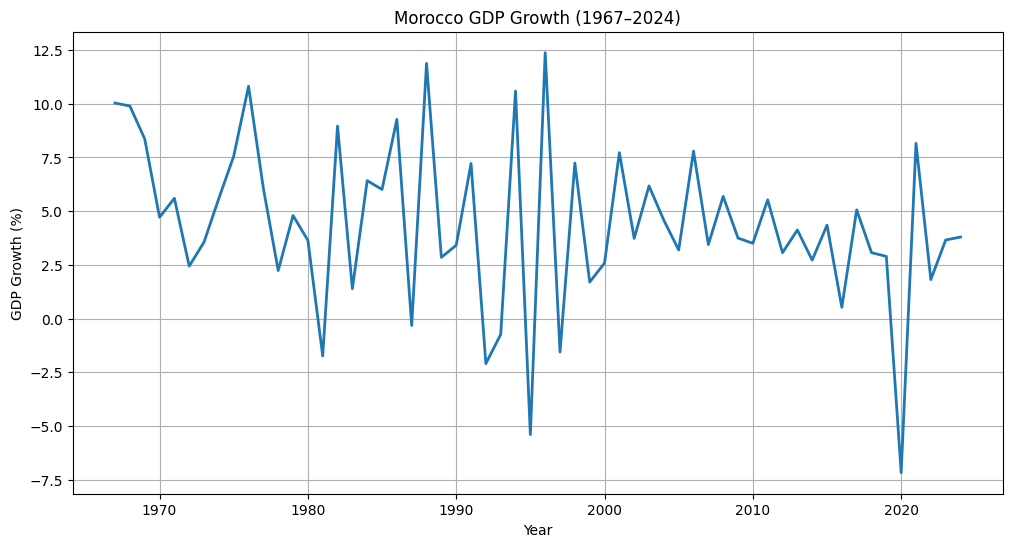

In [44]:
plt.figure(figsize=(12,6))

plt.plot(
    gdp_df["year"],
    gdp_df["value"],
    linewidth=2
)

plt.title("Morocco GDP Growth (1967–2024)")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")

plt.grid(True)

plt.show()

### Interpretation

Morocco maintained positive economic growth during most of the period between 1967 and 2024.

Although the economy experienced several fluctuations, the long-term trend remained positive, with an average growth rate of approximately 4.4%.

The chart also highlights periods of economic slowdown, including a significant contraction around 2020, which reflects the impact of the COVID-19 pandemic.

Overall, the results suggest that Morocco has demonstrated long-term economic resilience while continuing to recover from temporary economic shocks.

## GDP Per Capita Analysis

GDP per capita measures the average economic output per person.

It is commonly used as an indicator of economic development and living standards.

Analyzing GDP per capita helps us understand how Morocco's economy has evolved over time and provides additional context for the country's preparation for major international sporting events.

In [45]:
gdp_pc_df = economic_df[
    economic_df["indicator_name"] == "GDP per capita current US$"
].copy()

gdp_pc_df = gdp_pc_df.dropna(subset=["value"])

gdp_pc_df[["year", "value"]].describe()

,year,value
count,65.00000,65.000000
mean,1992.00000,1601.064354
std,18.90767,1230.305207
min,1960.00000,169.318436
25%,1976.00000,543.368469
50%,1992.00000,1292.233765
75%,2008.00000,3067.985352
max,2024.00000,4153.194336


## GDP Per Capita Trend Over Time

GDP per capita helps measure economic development by showing the average economic output per person.

The following chart illustrates how GDP per capita evolved in Morocco between 1960 and 2024.

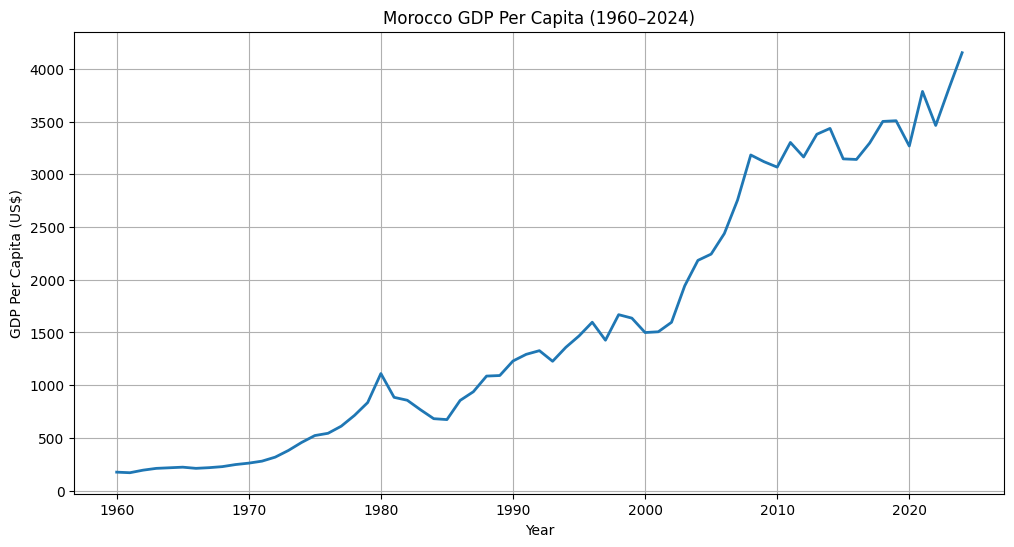

In [46]:
plt.figure(figsize=(12,6))

plt.plot(
    gdp_pc_df["year"],
    gdp_pc_df["value"],
    linewidth=2
)

plt.title("Morocco GDP Per Capita (1960–2024)")
plt.xlabel("Year")
plt.ylabel("GDP Per Capita (US$)")

plt.grid(True)

plt.show()

### Interpretation

The chart shows a strong long-term increase in Morocco's GDP per capita between 1960 and 2024.

GDP per capita increased from approximately $169 in 1960 to more than $4,100 in 2024, reflecting significant economic development over the last six decades.

Although some periods experienced slower growth, the overall trend remained strongly positive.

This upward trajectory suggests that Morocco has steadily expanded its economic capacity, providing a stronger foundation for large-scale investments related to AFCON 2025 and the FIFA World Cup 2030.

## Unemployment Analysis

Unemployment measures the percentage of the labor force that is actively seeking work but unable to find employment.

Analyzing unemployment helps determine whether economic growth has translated into better employment opportunities over time.

In [47]:
unemployment_df = economic_df[
    economic_df["indicator_name"] == "Unemployment total %"
].copy()

unemployment_df = unemployment_df.dropna(subset=["value"])

unemployment_df[["year", "value"]].describe()

,year,value
count,35.000000,35.000000
mean,2008.000000,10.959200
std,10.246951,1.999523
min,1991.000000,8.896000
25%,1999.500000,9.225000
50%,2008.000000,9.700000
75%,2016.500000,13.360500
max,2025.000000,14.054000


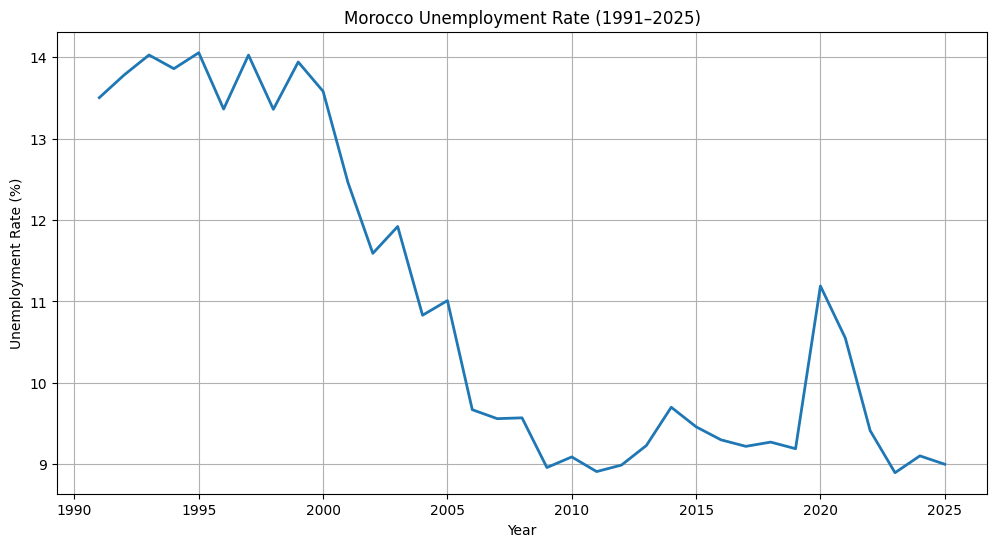

In [48]:
plt.figure(figsize=(12,6))

plt.plot(
    unemployment_df["year"],
    unemployment_df["value"],
    linewidth=2
)

plt.title("Morocco Unemployment Rate (1991–2025)")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)

plt.show()

### Interpretation

The unemployment rate declined significantly between the early 1990s and the late 2000s, falling from approximately 14% to around 9%.

This improvement suggests that Morocco's economic development during this period was accompanied by stronger employment opportunities.

After a relatively stable decade, unemployment increased during the COVID-19 period, reflecting the impact of the global economic slowdown.

Recent data indicates a gradual recovery, with unemployment rates returning closer to pre-pandemic levels.

## Inflation Analysis

Inflation measures the rate at which prices increase over time.

Maintaining stable inflation is important for economic growth, consumer purchasing power, and long-term investment planning.

In this section, we analyze how inflation evolved in Morocco over time.

In [49]:
inflation_df = economic_df[
    economic_df["indicator_name"] == "Inflation consumer prices annual %"
].copy()

inflation_df = inflation_df.dropna(subset=["value"])

inflation_df[["year", "value"]].describe()

,year,value
count,65.00000,65.000000
mean,1992.00000,4.148950
std,18.90767,3.782683
min,1960.00000,-1.013579
25%,1976.00000,1.279181
50%,1992.00000,2.986809
75%,2008.00000,6.123582
max,2024.00000,17.556823


## Inflation Trend Over Time

Inflation affects purchasing power, investment decisions, and economic stability.

The following chart illustrates how inflation evolved in Morocco between 1960 and 2024.

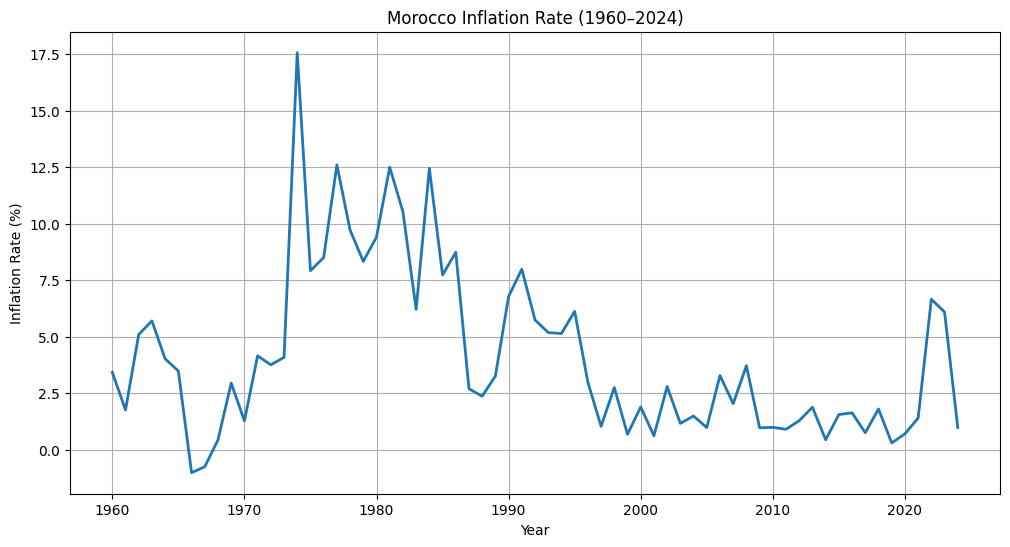

In [50]:
plt.figure(figsize=(12,6))

plt.plot(
    inflation_df["year"],
    inflation_df["value"],
    linewidth=2
)

plt.title("Morocco Inflation Rate (1960–2024)")
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")

plt.grid(True)

plt.show()

### Interpretation

The inflation rate experienced significant fluctuations during the 1970s and 1980s, including a peak of approximately 17.6%.

Over time, inflation became considerably more stable, with most values remaining below 5% from the late 1990s onward.

A temporary increase occurred during the post-pandemic period, reflecting global inflationary pressures observed across many countries.

Overall, the long-term trend suggests that Morocco has maintained relatively stable price levels during recent decades, supporting a more predictable economic environment for investment and development projects.

## Foreign Direct Investment (FDI) Analysis

Foreign Direct Investment (FDI) represents investments made by foreign companies and investors in Morocco.

FDI is often considered an indicator of investor confidence and economic attractiveness.

Analyzing FDI helps assess Morocco's ability to attract international capital before major sporting events.

In [51]:
fdi_df = economic_df[
    economic_df["indicator_name"] == "Foreign direct investment net inflows"
].copy()

fdi_df = fdi_df.dropna(subset=["value"])

fdi_df[["year", "value"]].describe()

,year,value
count,55.00000,5.500000e+01
mean,1997.00000,1.081237e+09
std,16.02082,1.170398e+09
min,1970.00000,-2.040000e+07
25%,1983.50000,5.278527e+07
50%,1997.00000,4.803557e+08
75%,2010.50000,2.208756e+09
max,2024.00000,3.544387e+09


### Initial Observations

The FDI dataset contains 55 observations between 1970 and 2024.

Key findings:

- Average annual FDI inflow: approximately $1.08 billion
- Median annual FDI inflow: approximately $480 million
- Lowest value: approximately -$20 million
- Highest value: approximately $3.54 billion

The large difference between the median and maximum values suggests that Morocco experienced periods of exceptionally strong foreign investment, particularly during recent decades.

## Foreign Direct Investment Trend Over Time

Foreign Direct Investment (FDI) is an important indicator of investor confidence and economic attractiveness.

The following chart shows how foreign investment inflows evolved in Morocco between 1970 and 2024.

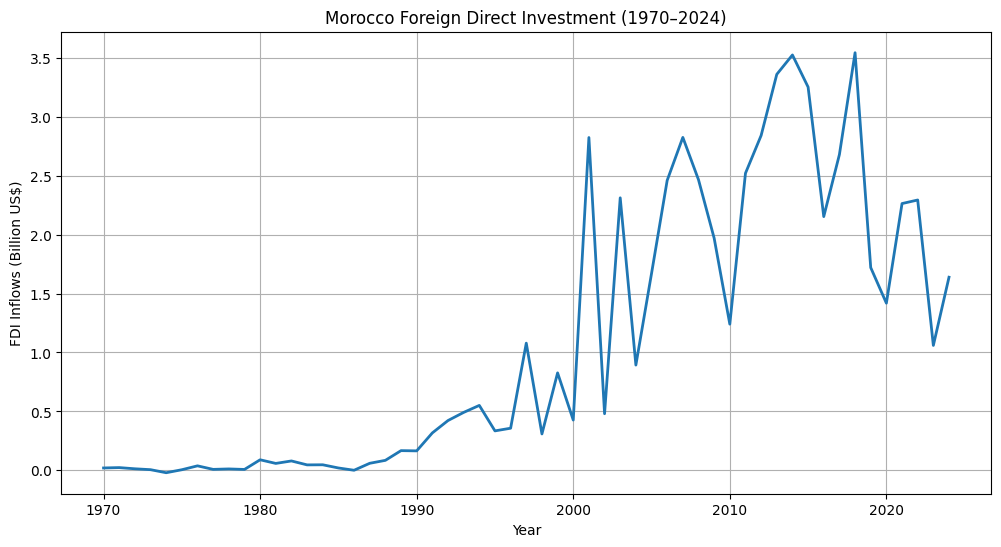

In [52]:
plt.figure(figsize=(12,6))

plt.plot(
    fdi_df["year"],
    fdi_df["value"] / 1_000_000_000,
    linewidth=2
)

plt.title("Morocco Foreign Direct Investment (1970–2024)")
plt.xlabel("Year")
plt.ylabel("FDI Inflows (Billion US$)")

plt.grid(True)

plt.show()

### Interpretation

The FDI trend is considerably more volatile than the other economic indicators analyzed in this project.

While foreign investment inflows fluctuated significantly from year to year, the long-term trend shows a substantial increase compared to the 1970s and 1980s.

Beginning in the 1990s, Morocco attracted larger amounts of foreign capital, with several years exceeding $2 billion in annual inflows.

Although investor activity remains sensitive to economic conditions and major investment projects, the overall trend suggests that Morocco has become increasingly attractive to international investors over time.

# Economic Findings

After analyzing GDP growth, GDP per capita, unemployment, inflation, and FDI, several important patterns emerge:

- Morocco maintained positive long-term economic growth.
- GDP per capita increased significantly over time.
- Unemployment generally declined despite temporary setbacks.
- Inflation became more stable in recent decades.
- Foreign investment increased substantially, although annual inflows remained volatile.

These indicators suggest that Morocco entered the AFCON 2025 and FIFA World Cup 2030 preparation period with a stronger economic foundation than in previous decades.

# Tourism Analysis

Tourism is one of the sectors expected to benefit the most from AFCON 2025 and the FIFA World Cup 2030.

In this section, we analyze Morocco's tourism indicators to better understand the country's historical tourism performance and its potential for future growth.

## Tourism Dataset Overview

Let's first explore the tourism dataset and understand the available indicators.

In [53]:
tourism_df.head()

,country,indicator_code,indicator_name,year,value,source
0,Morocco,ST.INT.ARVL,International tourism arrivals,1960,NaN,World Bank API
1,Morocco,ST.INT.ARVL,International tourism arrivals,1961,NaN,World Bank API
2,Morocco,ST.INT.ARVL,International tourism arrivals,1962,NaN,World Bank API
3,Morocco,ST.INT.ARVL,International tourism arrivals,1963,NaN,World Bank API
4,Morocco,ST.INT.ARVL,International tourism arrivals,1964,NaN,World Bank API


In [54]:
tourism_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         132 non-null    str    
 1   indicator_code  132 non-null    str    
 2   indicator_name  132 non-null    str    
 3   year            132 non-null    int64  
 4   value           52 non-null     float64
 5   source          132 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 6.3 KB


## Available Tourism Indicators

Let's verify which tourism indicators are available in the dataset.

In [55]:
tourism_df["indicator_name"].value_counts()

indicator_name
International tourism arrivals                66
International tourism receipts current US$    66
Name: count, dtype: int64

### Tourism Indicators

The tourism dataset contains two indicators:

- International tourism arrivals
- International tourism receipts (current US$)

Together, these indicators help evaluate both the volume of visitors and the economic contribution of tourism to Morocco.

## International Tourism Arrivals

Tourism arrivals represent the number of international visitors entering Morocco.

This indicator helps measure the attractiveness of Morocco as a tourism destination and provides important context for future events such as AFCON 2025 and the FIFA World Cup 2030.

In [56]:
arrivals_df = tourism_df[
    tourism_df["indicator_name"] == "International tourism arrivals"
].copy()

arrivals_df = arrivals_df.dropna(subset=["value"])

arrivals_df[["year", "value"]].describe()

,year,value
count,26.000000,2.600000e+01
mean,2007.500000,7.288000e+06
std,7.648529,3.329380e+06
min,1995.000000,2.752000e+06
25%,2001.250000,4.492500e+06
50%,2007.500000,7.239000e+06
75%,2013.750000,1.021925e+07
max,2020.000000,1.310900e+07


### Initial Observations

The tourism arrivals dataset contains 26 observations between 1995 and 2020.

Key findings:

- Average annual arrivals: approximately 7.3 million tourists
- Median annual arrivals: approximately 7.2 million tourists
- Lowest value: approximately 2.8 million tourists
- Highest value: approximately 13.1 million tourists

The large difference between the minimum and maximum values suggests significant growth in Morocco's tourism sector over time.

## International Tourism Arrivals Trend

The following chart illustrates how the number of international visitors evolved between 1995 and 2020.

This helps evaluate Morocco's long-term attractiveness as a tourism destination before AFCON 2025 and the FIFA World Cup 2030.

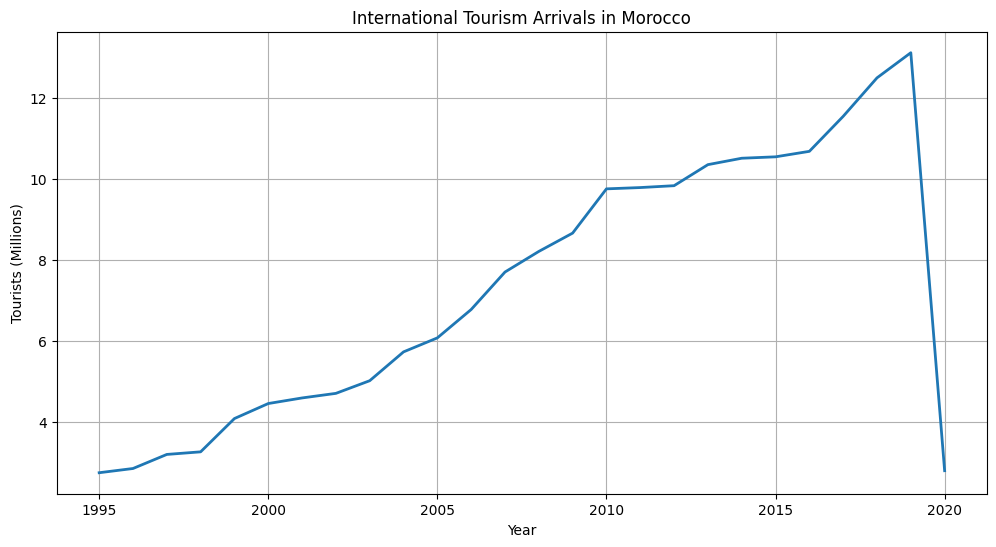

In [57]:
plt.figure(figsize=(12,6))

plt.plot(
    arrivals_df["year"],
    arrivals_df["value"] / 1_000_000,
    linewidth=2
)

plt.title("International Tourism Arrivals in Morocco")
plt.xlabel("Year")
plt.ylabel("Tourists (Millions)")

plt.grid(True)

plt.show()

### Interpretation

International tourism arrivals increased significantly between 1995 and 2020.

The number of visitors grew from approximately 2.8 million to more than 13 million tourists, highlighting the expansion of Morocco's tourism sector over the period.

The sharp decline observed around 2020 is likely linked to the global COVID-19 pandemic, which disrupted international travel and reduced tourism activity worldwide.

Despite this temporary setback, the long-term trend demonstrates Morocco's growing attractiveness as an international tourism destination.

In [58]:
receipts_df = tourism_df[
    tourism_df["indicator_name"] == "International tourism receipts current US$"
].copy()

receipts_df = receipts_df.dropna(subset=["value"])

receipts_df[["year", "value"]].describe()

,year,value
count,26.000000,2.600000e+01
mean,2007.500000,5.966308e+09
std,7.648529,3.005925e+09
min,1995.000000,1.469000e+09
25%,2001.250000,3.013750e+09
50%,2007.500000,7.332500e+09
75%,2013.750000,8.445000e+09
max,2020.000000,9.949000e+09


### Initial Observations

The tourism receipts dataset contains 26 observations between 1995 and 2020.

Key findings:

- Average tourism receipts: approximately $5.97 billion
- Median tourism receipts: approximately $7.33 billion
- Lowest value: approximately $1.47 billion
- Highest value: approximately $9.95 billion

The results indicate that tourism generated increasingly important revenues for Morocco over time, reaching nearly $10 billion before the pandemic period.

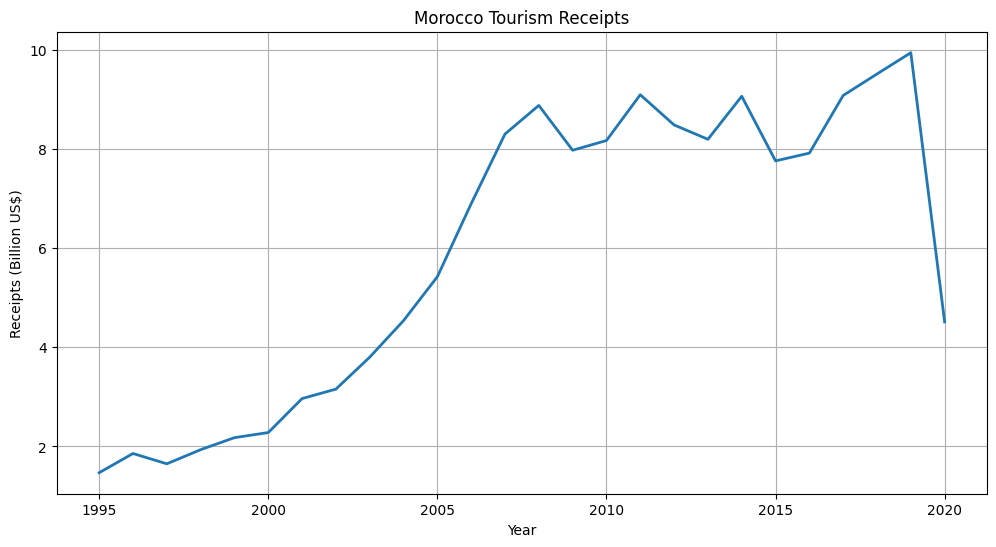

In [59]:
plt.figure(figsize=(12,6))

plt.plot(
    receipts_df["year"],
    receipts_df["value"] / 1_000_000_000,
    linewidth=2
)

plt.title("Morocco Tourism Receipts")
plt.xlabel("Year")
plt.ylabel("Receipts (Billion US$)")

plt.grid(True)

plt.show()

### Interpretation

Tourism receipts increased substantially between 1995 and the late 2000s, reflecting the rapid growth of Morocco's tourism sector.

After this expansion period, tourism revenues remained relatively stable, generating between $8 billion and $10 billion annually for several years.

This stability suggests that tourism became an established contributor to Morocco's economy.

A sharp decline occurred around 2020, corresponding to the global disruption of international travel during the COVID-19 pandemic.

Despite this temporary shock, the long-term trend demonstrates the growing economic importance of tourism in Morocco.

# Infrastructure Analysis

Infrastructure investment is one of the most important parts of Morocco's preparation for AFCON 2025 and the FIFA World Cup 2030.

This section analyzes major projects related to stadiums, airports, railways, ports, roads, and urban mobility.

In [60]:
infrastructure_df.head()

,id,project_name,city,project_type,investment_amount,status,start_year,end_year,source,created_at
0,1,Agadir Airport Upgrade,Agadir,Airport,NaN,Ongoing,2023,2027,Official Reports,2026-06-09 19:10:08.329832
1,2,Mohammed V Airport Expansion,Casablanca,Airport,NaN,Planned,2024,2029,Official Reports,2026-06-09 19:10:08.329832
2,3,Fez Airport Upgrade,Fes,Airport,NaN,Planned,2024,2030,Official Reports,2026-06-09 19:10:08.329832
3,4,Marrakech Airport Expansion,Marrakech,Airport,NaN,Planned,2024,2028,Official Reports,2026-06-09 19:10:08.329832
4,5,Rabat Sale Airport Expansion,Rabat,Airport,NaN,Planned,2024,2030,Official Reports,2026-06-09 19:10:08.329832


In [62]:
infrastructure_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 19 non-null     int64         
 1   project_name       19 non-null     str           
 2   city               19 non-null     str           
 3   project_type       19 non-null     str           
 4   investment_amount  4 non-null      float64       
 5   status             19 non-null     str           
 6   start_year         19 non-null     int64         
 7   end_year           19 non-null     int64         
 8   source             19 non-null     str           
 9   created_at         19 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(3), str(5)
memory usage: 1.6 KB


In [61]:
infrastructure_df["project_type"].value_counts()

project_type
Stadium                7
Airport                6
Port                   2
Urban Mobility         2
Railway                1
Road Infrastructure    1
Name: count, dtype: int64

### Interpretation

Stadium and airport projects represent the largest categories in the dataset.

This is consistent with the requirements of hosting international sporting events, which depend heavily on transportation infrastructure and modern sports facilities.

Additional investments were also made in ports, railways, roads, and urban mobility systems, supporting broader economic and logistical development.

## Infrastructure Projects Visualization

A visual representation makes it easier to compare the number of projects across different infrastructure categories.

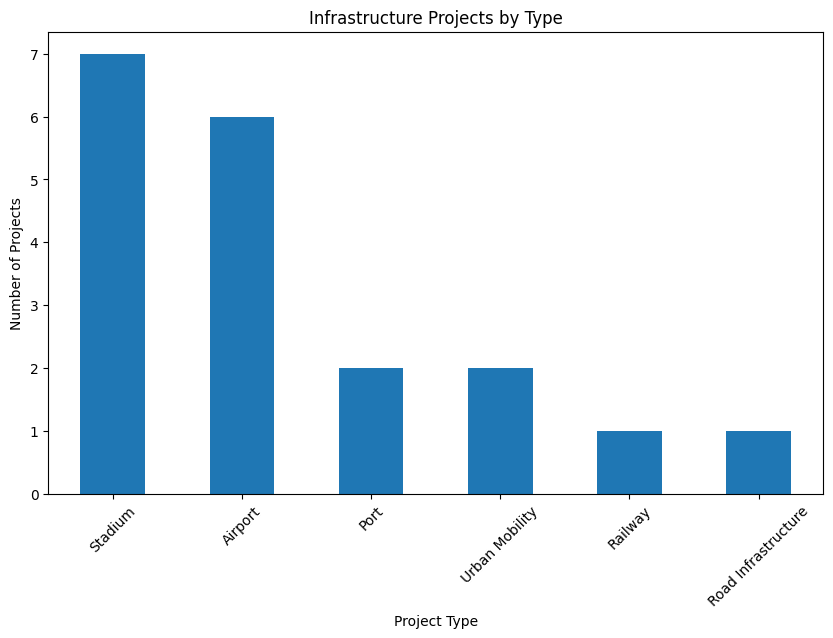

In [63]:
project_counts = (
    infrastructure_df["project_type"]
    .value_counts()
)

plt.figure(figsize=(10,6))

project_counts.plot(kind="bar")

plt.title("Infrastructure Projects by Type")
plt.xlabel("Project Type")
plt.ylabel("Number of Projects")

plt.xticks(rotation=45)

plt.show()

### Interpretation

The chart confirms that stadium and airport projects account for the majority of infrastructure investments in the dataset.

This reflects the importance of transportation capacity and sports facilities when preparing to host large international sporting events.

At the same time, investments in ports, railways, roads, and urban mobility demonstrate that the benefits of these projects extend beyond the sporting events themselves and contribute to broader economic development.

## Infrastructure Investment Analysis

The number of projects alone does not fully reflect the scale of Morocco's preparations.

In this section, we examine the investment amounts associated with major infrastructure projects.

In [64]:
infrastructure_df[
    ["project_name", "project_type", "investment_amount"]
].sort_values(
    by="investment_amount",
    ascending=False
).head(10)

,project_name,project_type,investment_amount
8,Kenitra Marrakech High Speed Rail,Railway,5.300000e+10
6,Nador West Med Port,Port,9.400000e+09
11,Grand Stade Hassan II,Stadium,5.000000e+09
15,Prince Moulay Abdellah Stadium Reconstruction,Stadium,6.860000e+08
0,Agadir Airport Upgrade,Airport,NaN
1,Mohammed V Airport Expansion,Airport,NaN
2,Fez Airport Upgrade,Airport,NaN
3,Marrakech Airport Expansion,Airport,NaN
4,Rabat Sale Airport Expansion,Airport,NaN
5,Tangier Airport Expansion,Airport,NaN


### Interpretation

The investment analysis reveals that transportation infrastructure represents the largest share of quantified investments in the dataset.

The Kenitra–Marrakech High Speed Rail project alone accounts for approximately 53 billion MAD, making it the largest project identified in the analysis.

Other major investments include the Nador West Med Port project and the construction of Grand Stade Hassan II.

These results suggest that Morocco's preparation strategy extends beyond sporting infrastructure and includes large-scale transportation and logistics projects designed to generate long-term economic benefits.

Several airport projects do not currently contain investment values, therefore the analysis focuses only on projects with available financial information.

## Largest Infrastructure Investments

The following chart highlights the largest quantified infrastructure investments included in the dataset.

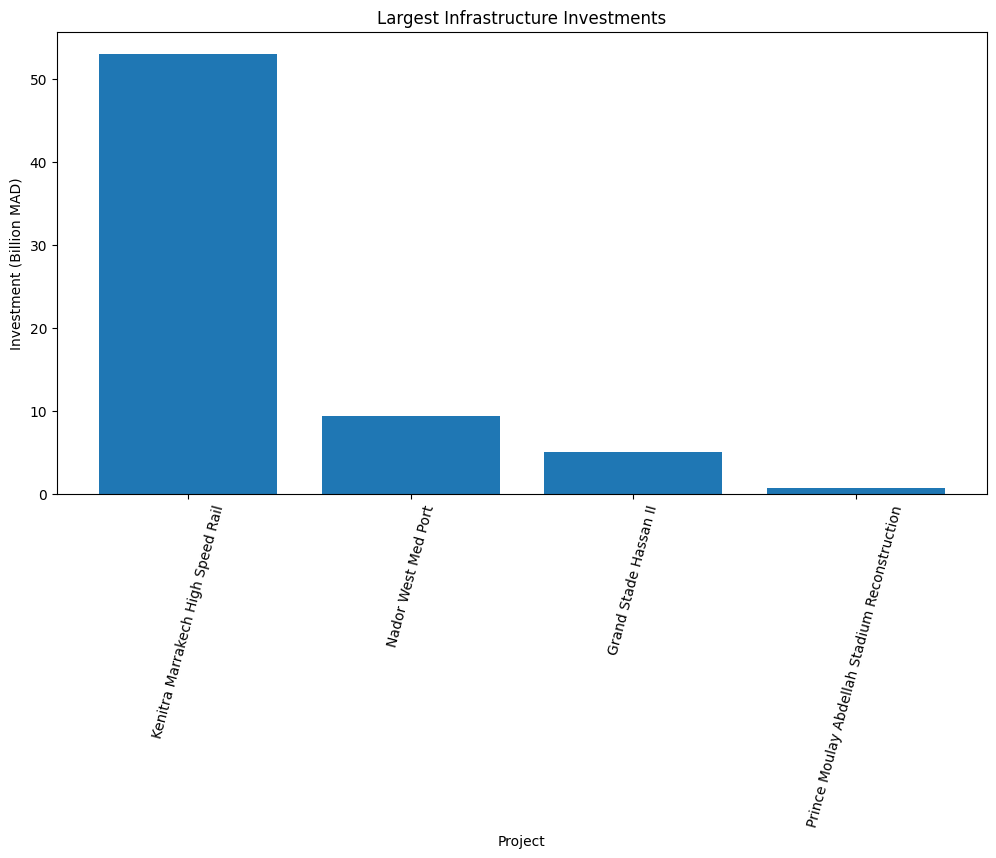

In [65]:
top_projects = infrastructure_df[
    infrastructure_df["investment_amount"].notna()
].sort_values(
    by="investment_amount",
    ascending=False
)

plt.figure(figsize=(12,6))

plt.bar(
    top_projects["project_name"],
    top_projects["investment_amount"] / 1_000_000_000
)

plt.title("Largest Infrastructure Investments")
plt.xlabel("Project")
plt.ylabel("Investment (Billion MAD)")

plt.xticks(rotation=75)

plt.show()

### Interpretation

The Kenitra–Marrakech High Speed Rail project dominates the investment landscape, with a budget significantly larger than any other quantified project in the dataset.

This highlights the strategic importance of transportation connectivity in Morocco's preparation for AFCON 2025 and the FIFA World Cup 2030.

While stadium and port projects also represent substantial investments, their financial scale remains considerably smaller than the high-speed rail expansion project.

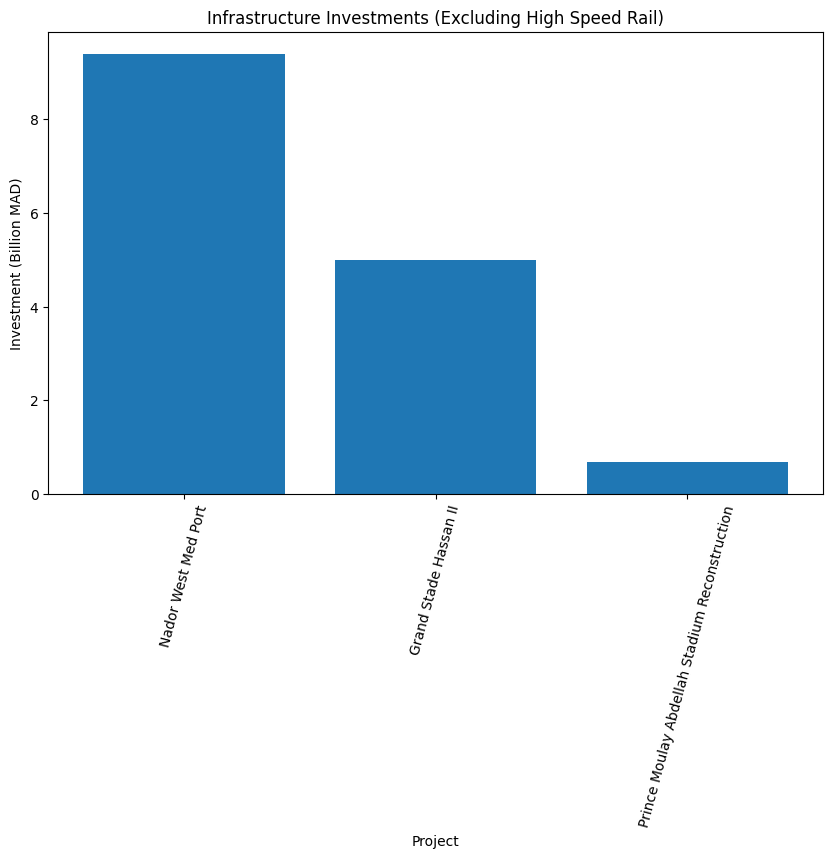

In [66]:
other_projects = infrastructure_df[
    (infrastructure_df["investment_amount"].notna()) &
    (infrastructure_df["project_name"] != "Kenitra Marrakech High Speed Rail")
]

plt.figure(figsize=(10,6))

plt.bar(
    other_projects["project_name"],
    other_projects["investment_amount"] / 1_000_000_000
)

plt.title("Infrastructure Investments (Excluding High Speed Rail)")
plt.xlabel("Project")
plt.ylabel("Investment (Billion MAD)")

plt.xticks(rotation=75)

plt.show()

### Interpretation

The High-Speed Rail project is the largest investment in the dataset.

After it, the Nador West Med Port and Grand Stade Hassan II projects represent the most significant investments.

This suggests that Morocco's preparation strategy focuses on both transportation infrastructure and sports facilities.

## Projects by City

Let's see which cities host the largest number of infrastructure projects.

In [67]:
infrastructure_df["city"].value_counts()

city
Casablanca    3
Rabat         3
Tangier       3
Agadir        2
Fes           2
Marrakech     2
Benslimane    2
Nador         1
Morocco       1
Name: count, dtype: int64

### Interpretation

Casablanca, Rabat, and Tangier contain the highest number of projects in the dataset.

Most host cities received multiple infrastructure investments, suggesting that preparations are spread across several regions rather than concentrated in a single location.

This reflects the national scale of Morocco's preparations for AFCON 2025 and the FIFA World Cup 2030.

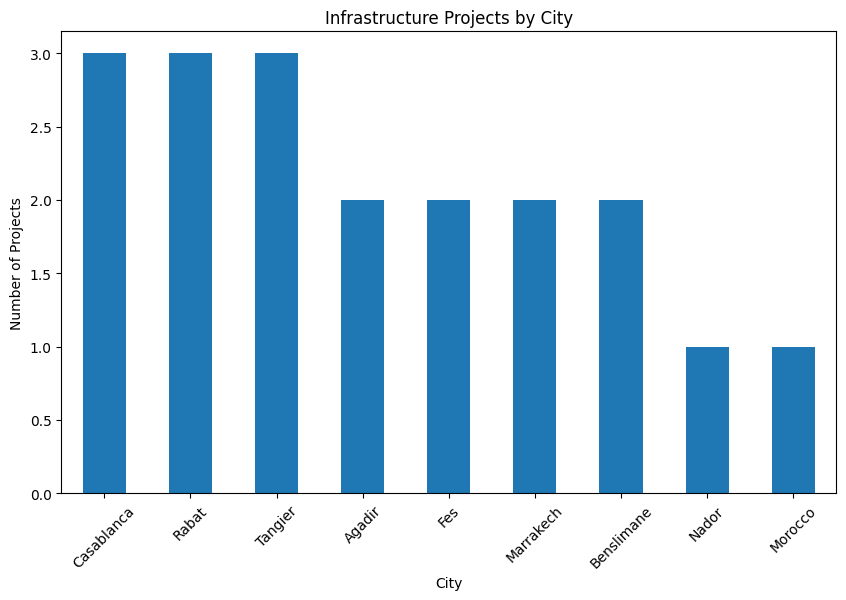

In [68]:
city_counts = infrastructure_df["city"].value_counts()

plt.figure(figsize=(10,6))

city_counts.plot(kind="bar")

plt.title("Infrastructure Projects by City")
plt.xlabel("City")
plt.ylabel("Number of Projects")

plt.xticks(rotation=45)

plt.show()

# Infrastructure Findings

Key findings:

- Stadiums and airports are the most common project types.
- The Kenitra–Marrakech High Speed Rail project is the largest investment.
- Nador West Med Port and Grand Stade Hassan II are major strategic projects.
- Infrastructure investments are distributed across multiple host cities.
- Morocco's preparation strategy combines sports facilities, transportation, and logistics infrastructure.

# Host Cities Analysis

Morocco's World Cup and AFCON preparations involve several host cities.

This section examines the cities selected to host major sporting events.

In [69]:
host_cities_df.head()

,id,city,event_name,region,population,source,created_at
0,1,Casablanca,World Cup 2030,Casablanca-Settat,3360000.0,Official Reports,2026-06-09 19:10:13.835889
1,2,Fes,World Cup 2030,Fes-Meknes,1250000.0,Official Reports,2026-06-09 19:10:13.835889
2,3,Tangier,World Cup 2030,Tanger-Tetouan-Al Hoceima,1200000.0,Official Reports,2026-06-09 19:10:13.835889
3,4,Marrakech,World Cup 2030,Marrakech-Safi,1100000.0,Official Reports,2026-06-09 19:10:13.835889
4,5,Agadir,World Cup 2030,Souss-Massa,950000.0,Official Reports,2026-06-09 19:10:13.835889


In [72]:
host_cities_df.columns

Index(['id', 'city', 'event_name', 'region', 'population', 'source',
       'created_at'],
      dtype='str')

In [71]:
host_cities_df["city"].value_counts()

city
Casablanca    1
Fes           1
Tangier       1
Marrakech     1
Agadir        1
Rabat         1
Benslimane    1
Name: count, dtype: int64

### Interpretation

The project includes seven host cities distributed across different regions of Morocco.

This geographic distribution helps spread the economic impact of infrastructure investments and tourism activity across the country.

## Host City Population

In [73]:
host_cities_df[
    ["city", "population"]
].sort_values(
    by="population",
    ascending=False
)

,city,population
0,Casablanca,3360000.0
1,Fes,1250000.0
2,Tangier,1200000.0
3,Marrakech,1100000.0
4,Agadir,950000.0
5,Rabat,580000.0
6,Benslimane,150000.0


### Interpretation

The selected host cities include some of Morocco's largest urban centers.

Large populations can support transportation systems, accommodation capacity, workforce availability, and event operations during major sporting events.

# Host Cities Findings

Key findings:

- The project includes 7 host cities.
- Infrastructure projects are distributed across multiple regions.
- Casablanca, Rabat, and Tangier host the highest number of projects.
- Host cities include some of Morocco's largest population centers.

These results suggest that Morocco's preparation efforts are geographically distributed and designed to benefit multiple regions.

# AFCON 2025 & World Cup 2030 Event Infrastructure

This section focuses on the infrastructure projects most directly connected to Morocco's preparation for AFCON 2025 and the FIFA World Cup 2030.

## Stadium Projects

In [90]:
stadium_projects = infrastructure_df[
    infrastructure_df["project_type"] == "Stadium"
]

stadium_projects[
    ["project_name", "city", "status", "start_year", "end_year", "investment_amount"]
]

,project_name,city,status,start_year,end_year,investment_amount
10,Agadir Stadium Upgrade,Agadir,Ongoing,2024,2026,NaN
11,Grand Stade Hassan II,Benslimane,Under Construction,2024,2028,5.000000e+09
12,Mohammed V Stadium Renovation,Casablanca,Ongoing,2024,2025,NaN
13,Fez Stadium Upgrade,Fes,Ongoing,2024,2026,NaN
14,Marrakech Stadium Upgrade,Marrakech,Ongoing,2024,2026,NaN
15,Prince Moulay Abdellah Stadium Reconstruction,Rabat,Under Construction,2023,2025,6.860000e+08
16,Ibn Batouta Stadium Upgrade,Tangier,Ongoing,2024,2026,NaN


### Interpretation

The dataset includes seven stadium projects across Casablanca, Rabat, Tangier, Agadir, Marrakech, Fes, and Benslimane.

The largest stadium investment is Grand Stade Hassan II in Benslimane, followed by Prince Moulay Abdellah Stadium in Rabat.

These projects represent the core sports infrastructure linked to AFCON 2025 and the FIFA World Cup 2030.

## Airport Projects

In [91]:
airport_projects = infrastructure_df[
    infrastructure_df["project_type"] == "Airport"
]

airport_projects[
    ["project_name", "city", "status", "start_year", "end_year"]
]

,project_name,city,status,start_year,end_year
0,Agadir Airport Upgrade,Agadir,Ongoing,2023,2027
1,Mohammed V Airport Expansion,Casablanca,Planned,2024,2029
2,Fez Airport Upgrade,Fes,Planned,2024,2030
3,Marrakech Airport Expansion,Marrakech,Planned,2024,2028
4,Rabat Sale Airport Expansion,Rabat,Planned,2024,2030
5,Tangier Airport Expansion,Tangier,Planned,2024,2030


### Interpretation

The dataset includes airport projects in Casablanca, Marrakech, Agadir, Rabat, Tangier, and Fes.

These projects are important because major sporting events require strong international transport capacity for tourists, teams, officials, and media.

## Project Timeline

In [92]:
infrastructure_df[
    ["project_name", "city", "project_type", "status", "start_year", "end_year"]
].sort_values("end_year")

,project_name,city,project_type,status,start_year,end_year
15,Prince Moulay Abdellah Stadium Reconstruction,Rabat,Stadium,Under Construction,2023,2025
12,Mohammed V Stadium Renovation,Casablanca,Stadium,Ongoing,2024,2025
16,Ibn Batouta Stadium Upgrade,Tangier,Stadium,Ongoing,2024,2026
14,Marrakech Stadium Upgrade,Marrakech,Stadium,Ongoing,2024,2026
13,Fez Stadium Upgrade,Fes,Stadium,Ongoing,2024,2026
10,Agadir Stadium Upgrade,Agadir,Stadium,Ongoing,2024,2026
0,Agadir Airport Upgrade,Agadir,Airport,Ongoing,2023,2027
6,Nador West Med Port,Nador,Port,Under Construction,2016,2027
17,Casablanca Tramway Extension,Casablanca,Urban Mobility,Ongoing,2023,2027
11,Grand Stade Hassan II,Benslimane,Stadium,Under Construction,2024,2028


### Interpretation

Some projects are planned to finish before AFCON 2025, while others extend toward 2028 and 2030.

This shows that Morocco's infrastructure preparation is not limited to one event, but forms a longer-term development plan leading toward the FIFA World Cup 2030.

In [93]:
infrastructure_df["status"].value_counts()

status
Ongoing               9
Planned               7
Under Construction    3
Name: count, dtype: int64

### Interpretation

The infrastructure dataset contains 19 major projects.

- 9 projects are currently ongoing.
- 7 projects are planned.
- 3 projects are already under construction.

These results suggest that Morocco's preparation efforts are actively progressing, with most projects already moving beyond the planning stage.

## Project Completion Timeline

Project completion dates help evaluate Morocco's readiness for AFCON 2025 and the FIFA World Cup 2030.

In [94]:
infrastructure_df["end_year"].value_counts().sort_index()

end_year
2025    2
2026    4
2027    3
2028    5
2029    1
2030    4
Name: count, dtype: int64

### Interpretation

The project timeline shows that Morocco's infrastructure investments are distributed across multiple years.

Project completions are expected as follows:

- 2025: 2 projects
- 2026: 4 projects
- 2027: 3 projects
- 2028: 5 projects
- 2029: 1 project
- 2030: 4 projects

The timeline suggests a phased preparation strategy.

Several projects are expected to be completed before or shortly after AFCON 2025, while major transportation and infrastructure projects continue toward the FIFA World Cup 2030.

This long-term approach indicates that Morocco's investments are designed not only for sporting events but also for broader economic and infrastructure development.

# Event Infrastructure Readiness Findings

- Morocco has 19 major infrastructure projects linked to AFCON 2025 and the FIFA World Cup 2030.
- Stadiums and airports are the most common project types.
- The Kenitra–Marrakech High Speed Rail project is the largest investment.
- Major projects are already ongoing, under construction, or planned.
- Project completion dates range from 2025 to 2030, supporting Morocco's long-term event preparation strategy.

# Machine Learning

To complement the analysis, a simple machine learning model is used to explore the relationship between Morocco's economic indicators and tourism arrivals.

In [95]:
#DATASET: 
economic_pivot = economic_df.pivot_table(
    index="year",
    columns="indicator_name",
    values="value"
).reset_index()

tourism_pivot = tourism_df.pivot_table(
    index="year",
    columns="indicator_name",
    values="value"
).reset_index()

ml_df = economic_pivot.merge(
    tourism_pivot,
    on="year",
    how="inner"
)

ml_df.shape

(26, 8)

## Random Forest Model

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = ml_df[
    [
        "GDP growth annual %",
        "GDP per capita current US$",
        "Inflation consumer prices annual %",
        "Unemployment total %",
        "Foreign direct investment net inflows"
    ]
]

y = ml_df["International tourism arrivals"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)

print("R² Score:", r2)

R² Score: 0.8439666779213442


## Machine Learning Findings

The Random Forest model achieved an R² score of approximately 0.84.

Although the dataset is relatively small, the results suggest that Morocco's economic indicators are strongly associated with tourism arrivals.

# Final Findings

- Morocco's economy has grown significantly over recent decades.
- Tourism arrivals increased from approximately 2.7 million to more than 13 million visitors.
- Tourism receipts increased from around $1.4 billion to nearly $10 billion.
- Morocco is investing heavily in transportation, stadiums, airports, and logistics infrastructure.
- The project includes 19 major infrastructure initiatives and 7 host cities.
- Most projects are already ongoing, under construction, or planned.
- Infrastructure completion dates extend from 2025 to 2030, supporting preparation for AFCON 2025 and the FIFA World Cup 2030.

## Conclusion

This project analyzed Morocco's economic indicators, tourism performance, infrastructure investments, and host city preparations in the context of AFCON 2025 and the FIFA World Cup 2030.

The results show strong growth in tourism, continued economic development, and significant investment in transportation and sports infrastructure.

The combination of stadium projects, airport expansions, railway investments, port developments, and host city preparations suggests that Morocco is actively preparing for these major international events while also supporting long-term economic development.